## Distribution of (op3, op4)

In [10]:
import json
import pickle
from pathlib import Path
from collections import defaultdict

# Paths
results_dir = Path("partition_results_das")
partition_path = results_dir / "partition_results_das_L5_P78_K2_200_op4.json"
graph_dataset_path = results_dir / "graph_dataset_200_op4.pkl"

# Load partition results
with open(partition_path) as f:
    results = json.load(f)

labels = results["labels"]  # cluster index per sample (0 or 1 for K=2)
n_samples = len(labels)
print(f"Loaded partition: {n_samples} samples, K={results['K']}, overall_iia={results['overall_iia']:.4f}\n")

# Load graph_dataset (same order as partition labels; each entry has base_labels with op3, op4)
with open(graph_dataset_path, "rb") as f:
    graph_dataset = pickle.load(f)

if len(graph_dataset) != n_samples:
    raise ValueError(f"Graph dataset size {len(graph_dataset)} != partition labels {n_samples}")

# Get (op3, op4) per sample
op1_values = [graph_dataset[i]["base_labels"]["op1"] for i in range(n_samples)]
op2_values = [graph_dataset[i]["base_labels"]["op2"] for i in range(n_samples)]
op3_values = [graph_dataset[i]["base_labels"]["op3"] for i in range(n_samples)]
op4_values = [graph_dataset[i]["base_labels"]["op4"] for i in range(n_samples)]

# Per-cluster: proportion in each (op3, op4) combination
cluster_ids = sorted(set(labels))
cols = ["(T,T)", "(T,F)", "(F,T)", "(F,F)"]
print("Distribution of (op1, op2) in each cluster:\n")
print(f"{'Cluster':<10} " + " ".join(f"{c:<10}" for c in cols) + " size")
print("-" * 56)

for c in cluster_ids:
    mask = [lab == c for lab in labels]
    n = sum(mask)
    counts = {
        (True, True): 0,
        (True, False): 0,
        (False, True): 0,
        (False, False): 0,
    }
    for i in range(n_samples):
        if mask[i]:
            counts[(op1_values[i], op2_values[i])] += 1
    props = [counts[(True, True)] / n, counts[(True, False)] / n, counts[(False, True)] / n, counts[(False, False)] / n] if n else [0, 0, 0, 0]
    print(f"{c:<10} " + " ".join(f"{p:<10.4f}" for p in props) + f" {n}")

Loaded partition: 199 samples, K=2, overall_iia=0.7552

Distribution of (op1, op2) in each cluster:

Cluster    (T,T)      (T,F)      (F,T)      (F,F)      size
--------------------------------------------------------
0          0.0000     0.2000     0.4154     0.3846     130
1          0.9130     0.0870     0.0000     0.0000     69


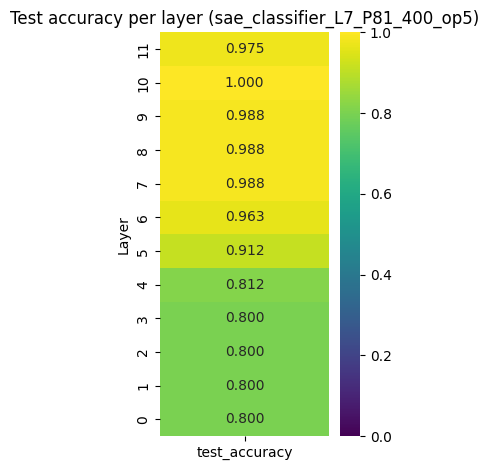

In [3]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Path to SAE classifier results
sae_results_path = Path("partition_results_das") / "sae_classifier_L7_P81_400_op5.json"

with open(sae_results_path) as f:
    sae_results = json.load(f)

layers = [entry["layer"] for entry in sae_results["results_per_layer"]]
test_accuracies = [entry["test_accuracy"] for entry in sae_results["results_per_layer"]]

# Reverse order so layer 0 is at the bottom and highest layer at the top
layers_rev = layers[::-1]
heatmap_data = np.array(test_accuracies)[::-1, None]

plt.figure(figsize=(3.0, max(4, len(layers) * 0.4)))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".3f",
    cmap="viridis",
    xticklabels=["test_accuracy"],
    yticklabels=layers_rev,
    vmin=0.0,
    vmax=1.0,
)
plt.ylabel("Layer")
plt.title("Test accuracy per layer (sae_classifier_L7_P81_400_op5)")
plt.tight_layout()
plt.show()

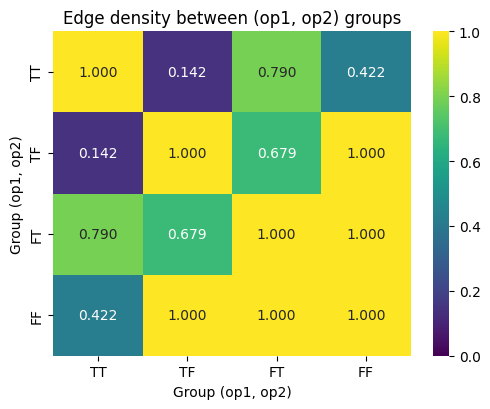

Group sizes (TT, TF, FT, FF): [63, 32, 54, 50]
Total nodes: 199 | total edges: 14879


In [11]:
# Edge density between groups defined by (op1, op2)
# Groups: TT (both True), TF, FT, FF

import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load graph (supports: numpy adjacency, scipy sparse adjacency, or networkx graph)
graph_path = results_dir / "graph_das_L5_P78_200_op4.pkl"
with open(graph_path, "rb") as f:
    G_or_adj = pickle.load(f)

try:
    import scipy.sparse as sp
except Exception:
    sp = None

try:
    import networkx as nx
except Exception:
    nx = None

if nx is not None and isinstance(G_or_adj, nx.Graph):
    # Ensure consistent node ordering 0..n-1 if possible
    n = G_or_adj.number_of_nodes()
    nodes = list(range(n)) if set(G_or_adj.nodes()) == set(range(n)) else list(G_or_adj.nodes())
    adj = nx.to_numpy_array(G_or_adj, nodelist=nodes)
else:
    adj = G_or_adj
    if sp is not None and sp.issparse(adj):
        adj = adj.toarray()
    adj = np.asarray(adj)

# Make sure we're working with a simple undirected (0/1) adjacency
adj = (adj != 0).astype(np.int64)
np.fill_diagonal(adj, 0)

# Group labels: TT, TF, FT, FF
group_names = ["TT", "TF", "FT", "FF"]
group_map = {(True, True): 0, (True, False): 1, (False, True): 2, (False, False): 3}

group_ids = np.array([group_map[(op1_values[i], op2_values[i])] for i in range(n_samples)])
indices_per_group = [np.where(group_ids == g)[0] for g in range(4)]

# Compute edge density matrix (4x4)
# - Within-group: edges / (n*(n-1)/2)
# - Between-groups: edges / (n_a*n_b)
# Counting assumes an undirected graph (symmetric adjacency).
density = np.full((4, 4), np.nan, dtype=float)
for ga in range(4):
    idx_a = indices_per_group[ga]
    na = len(idx_a)
    for gb in range(4):
        idx_b = indices_per_group[gb]
        nb = len(idx_b)
        if na == 0 or nb == 0:
            continue

        block = adj[np.ix_(idx_a, idx_b)]
        if ga == gb:
            # block includes both triangles; divide by 2 to get undirected edge count
            num_edges = int(block.sum()) // 2
            max_edges = na * (na - 1) // 2
            density[ga, gb] = (num_edges / max_edges) if max_edges > 0 else 0.0
        else:
            # between-group block counts each undirected edge exactly once (A->B)
            num_edges = int(block.sum())
            max_edges = na * nb
            density[ga, gb] = (num_edges / max_edges) if max_edges > 0 else 0.0

# Plot heatmap
fig, ax = plt.subplots(figsize=(5.2, 4.2))
sns.heatmap(
    density,
    annot=True,
    fmt=".3f",
    cmap="viridis",
    xticklabels=group_names,
    yticklabels=group_names,
    vmin=0.0,
    vmax=1.0,
    ax=ax,
)
ax.set_xlabel("Group (op1, op2)")
ax.set_ylabel("Group (op1, op2)")
ax.set_title("Edge density between (op1, op2) groups")
plt.tight_layout()
plt.show()

print("Group sizes (TT, TF, FT, FF):", [len(ix) for ix in indices_per_group])
print("Total nodes:", adj.shape[0], "| total edges:", int(adj.sum()) // 2)

In [12]:
# IIA for partition: Cluster 0 = (TF, FF), Cluster 1 = (TT, FT)

import numpy as np

# We assume `adj`, `group_ids`, and `n_samples` are already defined from previous cells.
# group_ids mapping (from earlier): 0=TT, 1=TF, 2=FT, 3=FF

# Build 2-cluster labeling: 0 -> {TF, FF}, 1 -> {TT, FT}
labels_2 = np.zeros(n_samples, dtype=int)
labels_2[np.isin(group_ids, [1, 3])] = 0  # TF, FF
labels_2[np.isin(group_ids, [0, 2])] = 1  # TT, FT


def compute_subgraph_iia(adj_matrix: np.ndarray, labels: np.ndarray, cluster_id: int) -> float:
    """Edge density for one cluster (undirected), same as in das_partition_graph.py."""
    mask = labels == cluster_id
    subgraph = adj_matrix[mask][:, mask]
    n = subgraph.shape[0]
    if n <= 1:
        return 0.0
    num_edges = int(np.sum(subgraph)) // 2
    max_edges = n * (n - 1) // 2
    return num_edges / max_edges if max_edges > 0 else 0.0


cluster_ids = np.unique(labels_2)
cluster_sizes = [int(np.sum(labels_2 == k)) for k in cluster_ids]
iia_by_cluster = {}
for k in cluster_ids:
    iia = compute_subgraph_iia(adj, labels_2, int(k))
    iia_by_cluster[int(k)] = iia
    size = int(np.sum(labels_2 == k))
    print(f"Cluster {k} (groups: {'TF,FF' if k == 0 else 'TT,FT'}): IIA = {iia:.4f} (size={size})")

avg_iia = float(np.mean(list(iia_by_cluster.values())))
weighted_avg_iia = float(np.average(list(iia_by_cluster.values()), weights=cluster_sizes))

print("\nSummary for partition (TF,FF) vs (TT,FT):")
print(f"  Average IIA: {avg_iia:.4f}")
print(f"  Weighted average IIA: {weighted_avg_iia:.4f}")
print(f"  Cluster sizes: {cluster_sizes}")

Cluster 0 (groups: TF,FF): IIA = 1.0000 (size=82)
Cluster 1 (groups: TT,FT): IIA = 0.8945 (size=117)

Summary for partition (TF,FF) vs (TT,FT):
  Average IIA: 0.9472
  Weighted average IIA: 0.9380
  Cluster sizes: [82, 117]


In [13]:
# Downsample TT to 50, then recompute IIA for partition: (TF,FF) vs (TT,FT)

import numpy as np

rng = np.random.default_rng(42)

# group_ids mapping: 0=TT, 1=TF, 2=FT, 3=FF
tt_idx = np.where(group_ids == 0)[0]
non_tt_idx = np.where(group_ids != 0)[0]

n_tt_keep = 60
if len(tt_idx) < n_tt_keep:
    raise ValueError(f"TT has only {len(tt_idx)} samples; cannot downsample to {n_tt_keep}.")

# Keep all non-TT nodes, plus a random subset of 50 TT nodes
tt_keep_idx = rng.choice(tt_idx, size=n_tt_keep, replace=False)
keep_idx = np.sort(np.concatenate([non_tt_idx, tt_keep_idx]))

# Induced subgraph on selected nodes
adj_ds = adj[np.ix_(keep_idx, keep_idx)]
group_ids_ds = group_ids[keep_idx]

# Build 2-cluster labels: 0 -> {TF, FF}, 1 -> {TT, FT}
labels_2_ds = np.zeros(len(keep_idx), dtype=int)
labels_2_ds[np.isin(group_ids_ds, [1, 2, 3])] = 0
labels_2_ds[np.isin(group_ids_ds, [0, 2])] = 1


def compute_subgraph_iia(adj_matrix: np.ndarray, labels: np.ndarray, cluster_id: int) -> float:
    mask = labels == cluster_id
    subgraph = adj_matrix[mask][:, mask]
    n = subgraph.shape[0]
    if n <= 1:
        return 0.0
    num_edges = int(np.sum(subgraph)) // 2
    max_edges = n * (n - 1) // 2
    return num_edges / max_edges if max_edges > 0 else 0.0


cluster_ids_ds = np.unique(labels_2_ds)
cluster_sizes_ds = [int(np.sum(labels_2_ds == k)) for k in cluster_ids_ds]

iia_by_cluster_ds = {}
for k in cluster_ids_ds:
    iia = compute_subgraph_iia(adj_ds, labels_2_ds, int(k))
    iia_by_cluster_ds[int(k)] = iia
    size = int(np.sum(labels_2_ds == k))
    print(f"Cluster {k} (groups: {'TF,FF' if k == 0 else 'TT,FT'}): IIA = {iia:.4f} (size={size})")

avg_iia_ds = float(np.mean(list(iia_by_cluster_ds.values())))
weighted_avg_iia_ds = float(np.average(list(iia_by_cluster_ds.values()), weights=cluster_sizes_ds))

print("\nDownsample details:")
print(f"  TT original: {len(tt_idx)}, TT kept: {len(tt_keep_idx)}")
print(f"  Total nodes after downsampling: {len(keep_idx)}")
print("\nSummary after TT downsampling (TF,FF) vs (TT,FT):")
print(f"  Average IIA: {avg_iia_ds:.4f}")
print(f"  Weighted average IIA: {weighted_avg_iia_ds:.4f}")
print(f"  Cluster sizes: {cluster_sizes_ds}")

Cluster 0 (groups: TF,FF): IIA = 1.0000 (size=82)
Cluster 1 (groups: TT,FT): IIA = 0.8938 (size=114)

Downsample details:
  TT original: 63, TT kept: 60
  Total nodes after downsampling: 196

Summary after TT downsampling (TF,FF) vs (TT,FT):
  Average IIA: 0.9469
  Weighted average IIA: 0.9382
  Cluster sizes: [82, 114]
